## ATIVIDADE 1

In [1]:
# Parameters (EC5)
m = 0.073 # (Kg)
g = 9.81 #(m/s^2)
k = 6.51e-5 #(Nm^2/A^2) 
x0 = 8.5e-3 #(m)
i0 = 1.2608 #(A)

In [2]:
# Resistance
R = 11.0 #(Ohm)
u0 = R*i0

In [3]:
eps = 0.03*x0
Kp = 1800
Ki = 500
Kd = 180

In [4]:
# Magnetic force fm
def fm(i,x):
    return k/2*i*i/x/x
# Force Factor
def Bl(i,x):
     return k/2*i/x/x #(N/A)
# Inductance
def L(x):
     return k/x #(H)

def odePDI(t,y):
    i,x,v,E = y
    e = x-x0
    u = u0 + Kp*e + Ki*E + Kd*v
    
    #di/dt
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u/L(x)
    #dx/dt
    dx = v
    #dv/dt
    dv = g-fm(i,x)/m
    #u(t)
    dE = e
   
    return [di, dx, dv, dE]

print("\nAt equilibrium:")
print("    i0 = ",i0)
print("    x0 = ",x0)
print("    fm = ",fm(i0,x0))
print("    mg = ",m*g)
print("    fm/fg (%) = ",fm(i0,x0)/(m*g)*100)


At equilibrium:
    i0 =  1.2608
    x0 =  0.0085
    fm =  0.7161525485397922
    mg =  0.71613
    fm/fg (%) =  100.00314866571603


In [5]:
from scipy.integrate import solve_ivp

# Initial conditions
# y = [i,x,v,E]
y_0 = [i0,x0,0.0,0.0]
# Time span
t_0 = 0.0
t_end = 30 #(s) 

sol = solve_ivp(odePDI, [t_0, t_end],y_0)

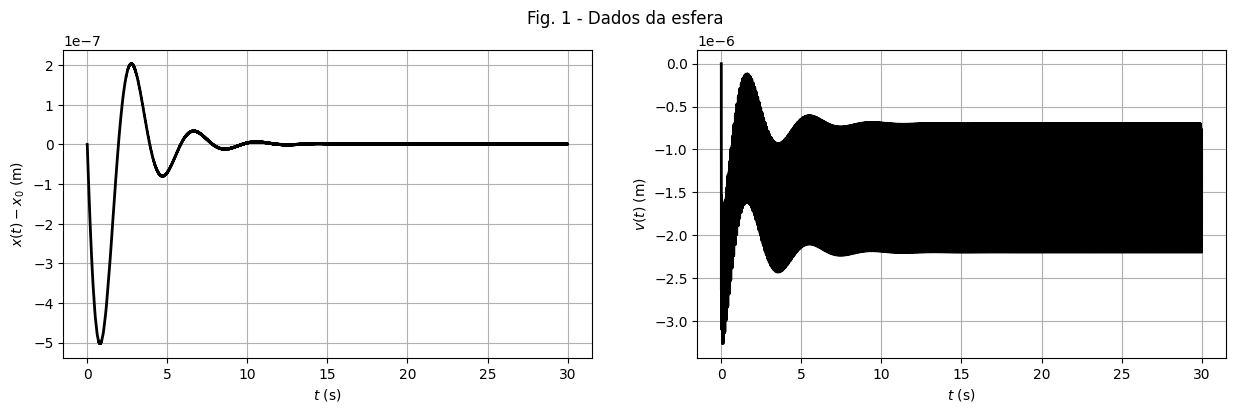

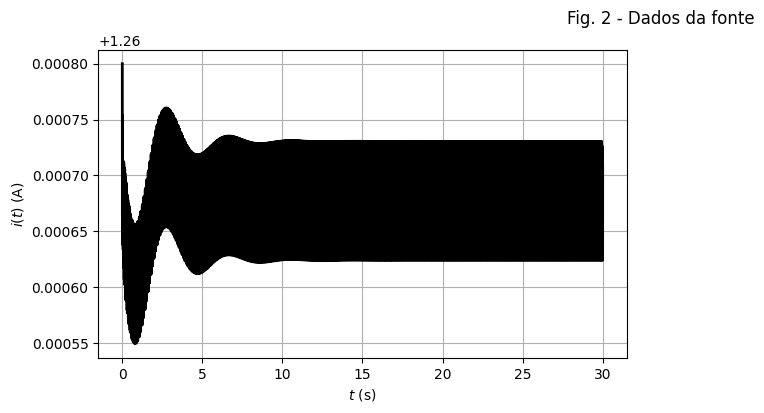

In [6]:
import matplotlib.pyplot as plt

# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[1,:]-x0, 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)-x_0$ (m)');
fig.suptitle('Fig. 1 - Dados da esfera');

plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
fig.suptitle('Fig. 2 - Dados da fonte');

## ATIVIDADE 2

In [7]:
Kp = 1800
Ki = 500
Kd = 180

In [8]:
import numpy as np

def odePDI(t,y):
    i,x,v,E = y
    noise = np.random.normal(0, 0.03 * x0)
    x_noise = x + noise 
    e = x_noise-x0
    u = u0 + Kp*e + Ki*E + Kd*v
    
    #di/dt
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u/L(x)
    #dx/dt
    dx = v
    #dv/dt
    dv = g-fm(i,x)/m
    #u(t)
    dE = e
   
    return [di, dx, dv, dE]

In [9]:
# Initial conditions
# y = [i,x,v,E]
y_0 = [i0,x0,0.0,0.0]
# Time span
t_0 = 0.0
t_end = 30 #(s) 

sol = solve_ivp(odePDI, [t_0, t_end],y_0)

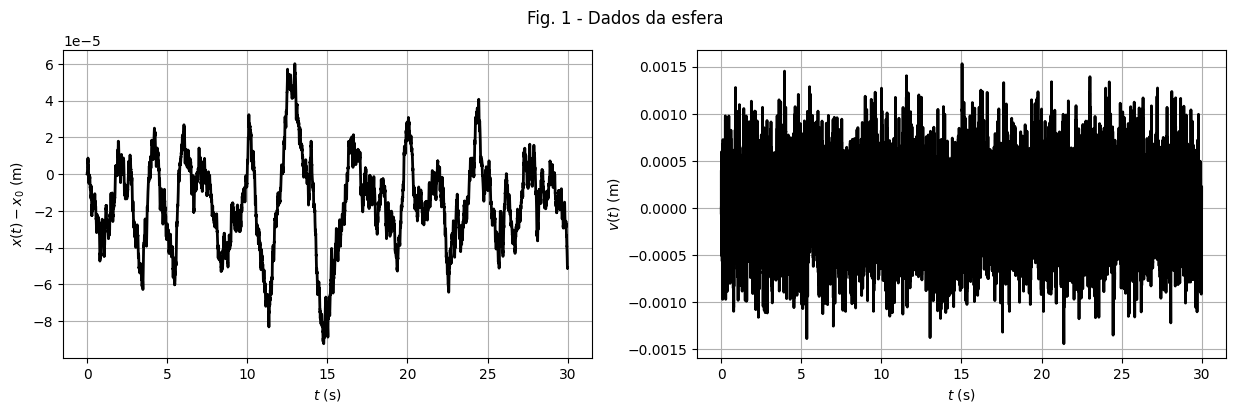

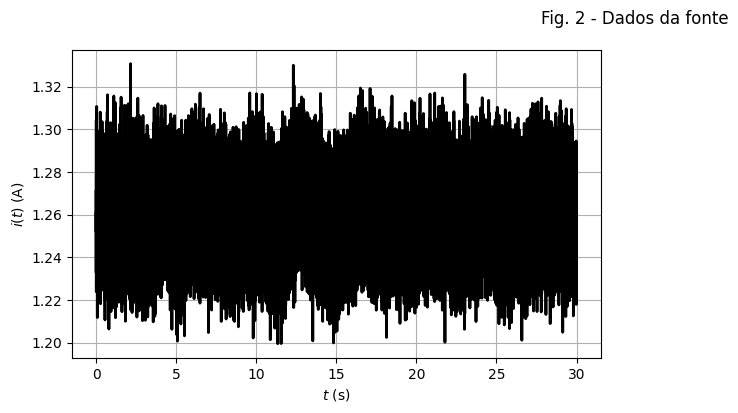

In [10]:
import matplotlib.pyplot as plt

# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[1,:]-x0, 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)-x_0$ (m)');
fig.suptitle('Fig. 1 - Dados da esfera');

plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
fig.suptitle('Fig. 2 - Dados da fonte');

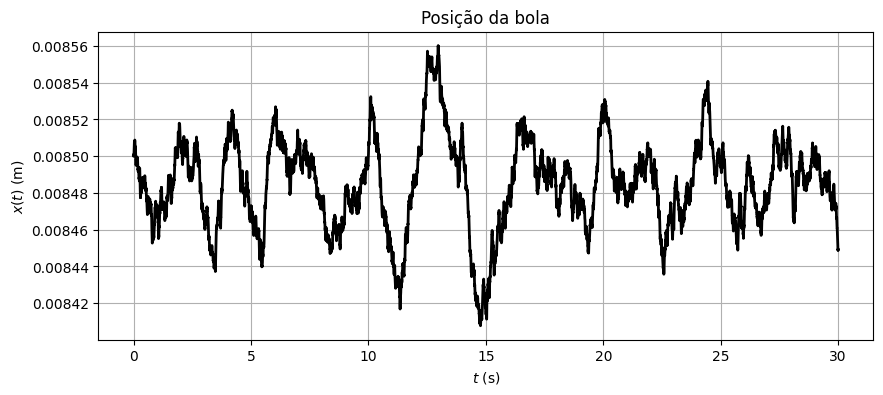

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(sol.t, sol.y[1,:], 'k', linewidth=2)
plt.grid(True)
plt.xlabel('$t$ (s)')
plt.ylabel('$x(t)$ (m)')
plt.title('Posição da bola')
plt.show()